# Import Packages

In [1]:
# Load in packages
# -------------------------------------- #
from momus.cosmicfit import CosmicFit
from momus.cosmicanalysis import CosmicAnalysis
from momus.syndata import generate_synthetic_data
import matplotlib.pyplot as plt
import numpy as np
# -------------------------------------- #

# Matplotlib Style 
# -------------------------------------- #
# fm.fontManager.__init__()
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({
    "font.family": "Palatino",
    "mathtext.fontset": "stix",
    "mathtext.rm": "Palatino",
    'font.size': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'axes.linewidth': 1.2,
    'legend.fontsize': 11
})
# -------------------------------------- #

### Test Data

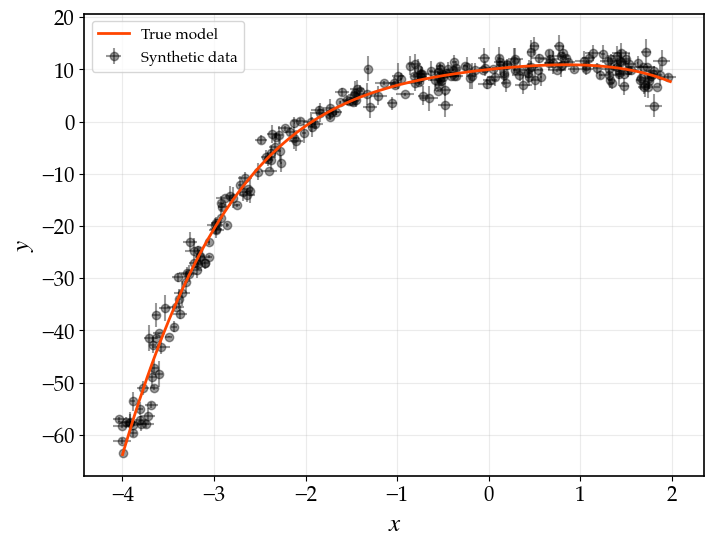

In [2]:

# Define Synthetic Model
# --------------------------------------------------- #
latex_eq = r"a_0 + a_1 x + a_2x^2 + a_3 x^3 + a_4 x^4"
coeffs_true = [10, 1.9, -0.9, 0.05, -0.19]
sigma_x_int_true = 0.05
sigma_y_int_true = 1
sigma_xy_int_true = 0
observed_xerr = 0.1
observed_yerr = 2.5
(x_true, y_true, x_obs, y_obs, x_err, y_err) = \
    generate_synthetic_data(n_data=250, 
                            latex_eq=latex_eq, coeffs_true=coeffs_true, x_range=(-4, 2), 
                            sigma_x_int=sigma_x_int_true, sigma_y_int=sigma_y_int_true, x_err_max=observed_xerr, y_err_max=observed_yerr, sigma_xy_int = sigma_xy_int_true, 
                            seed=1)
# --------------------------------------------------- #



# Plot
# --------------------------------------------------- #
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(x_obs, y_obs, xerr=x_err, yerr=y_err, fmt="o", color="black", alpha=0.4, label="Synthetic data")
ax.plot(x_true, y_true, color="orangered", lw=2, label="True model", zorder=10)

ax.grid(alpha=0.25)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()

plt.show()
# --------------------------------------------------- #


### Real Data (6-Order)

In [ ]:
import pandas as pd
latex_eq = r"a_0 + a_1 x + a_2 x^2 + a_3 x^3 + a_4 x^4 + a_5 x^5 + a_6 x^6"
df = pd.read_csv("/Users/hunter_brooks8/Documents/EOS/total_spec/EOS Sample - Platinum Sample.csv")
x_obs = df['sptnum_adp']
y_obs = df['Lbol']
Lbol_upper = np.abs(df['Lbol'] - df['Lbol_upper'])
Lbol_lower = np.abs(df['Lbol'] - df['Lbol_lower'])
y_err = 0.5*(Lbol_lower + Lbol_upper)

mask = np.isfinite(x_obs) & np.isfinite(y_obs) & np.isfinite(y_err)
x_obs = x_obs[mask]
y_obs = y_obs[mask]

x_err = [1]*len(y_err[mask])
y_err = y_err[mask]

plt.errorbar(x_obs, y_obs, xerr = x_err,yerr = y_err, fmt = 'o')

### Using Data


------------------------------------------
CosmicFit Model
------------------------------------------
LaTeX equation: a_0 + a_1 x + a_2x^2 + a_3 x^3 + a_4 x^4
Coefficients: [a_{0}, a_{1}, a_{2}, a_{3}, a_{4}]
Number of coefficients: 5
Total parameters: 8
------------------------------------------


------------------------------------------
Initial fit diagnostics
------------------------------------------
Initial coefficients: [10.12747825  1.56985692 -1.00707909  0.15539303 -0.16065888]
Initial residual scatter: 2.3716308659356655
Initial RMSE: 2.3716308659356655
Initial log posterior: -514.1358764957533
------------------------------------------



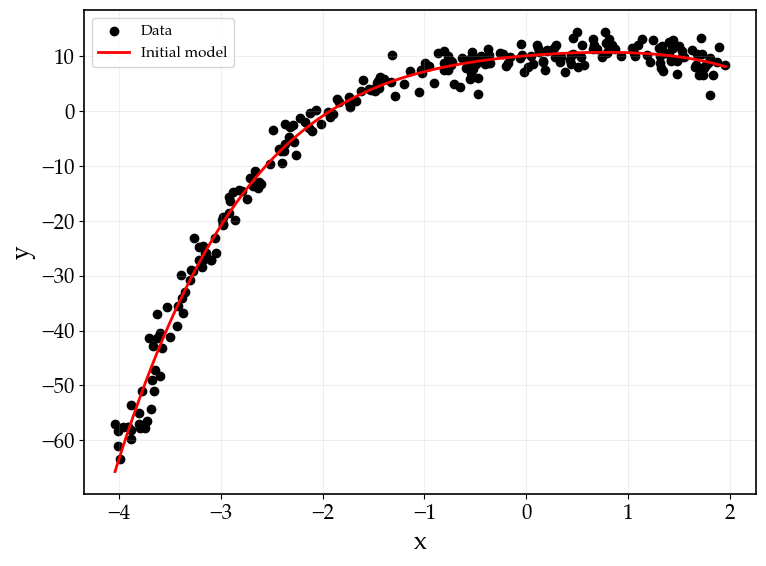

100%|██████████| 5000/5000 [01:08<00:00, 73.38it/s]


In [3]:
sampler = CosmicFit(x_obs, y_obs, xerr = x_err, yerr = y_err, nsteps=5000, nwalkers=50, ncores=6, quad_points = 250, latex_eq=latex_eq)
# 

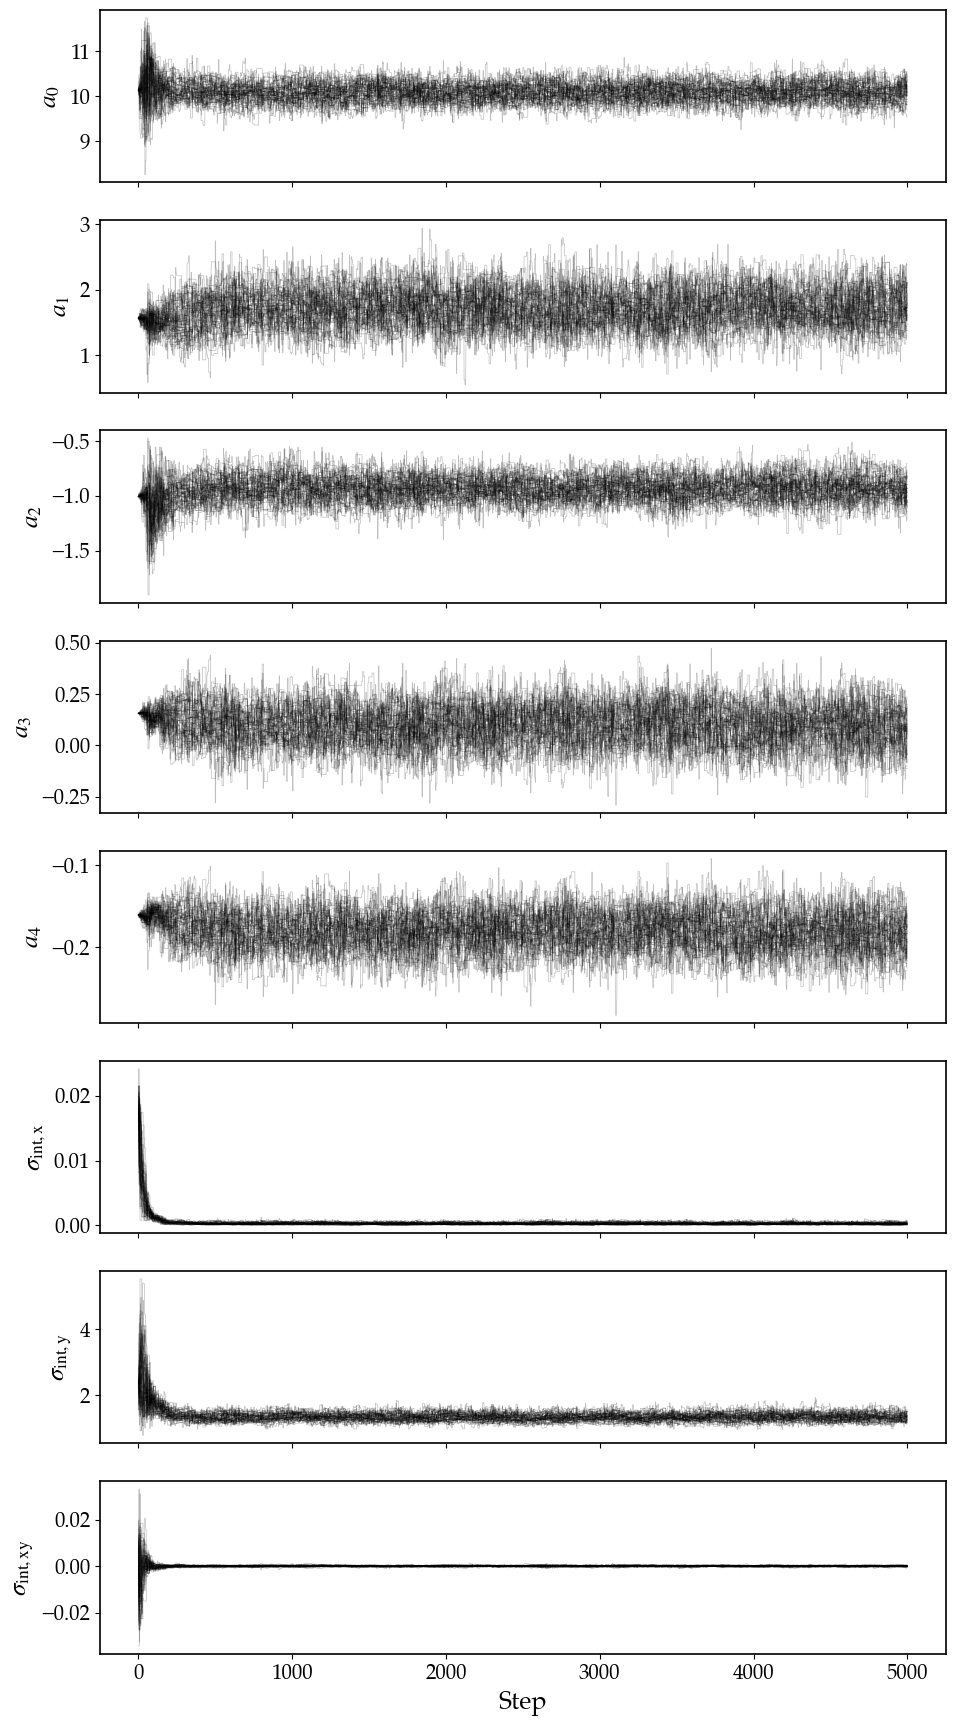

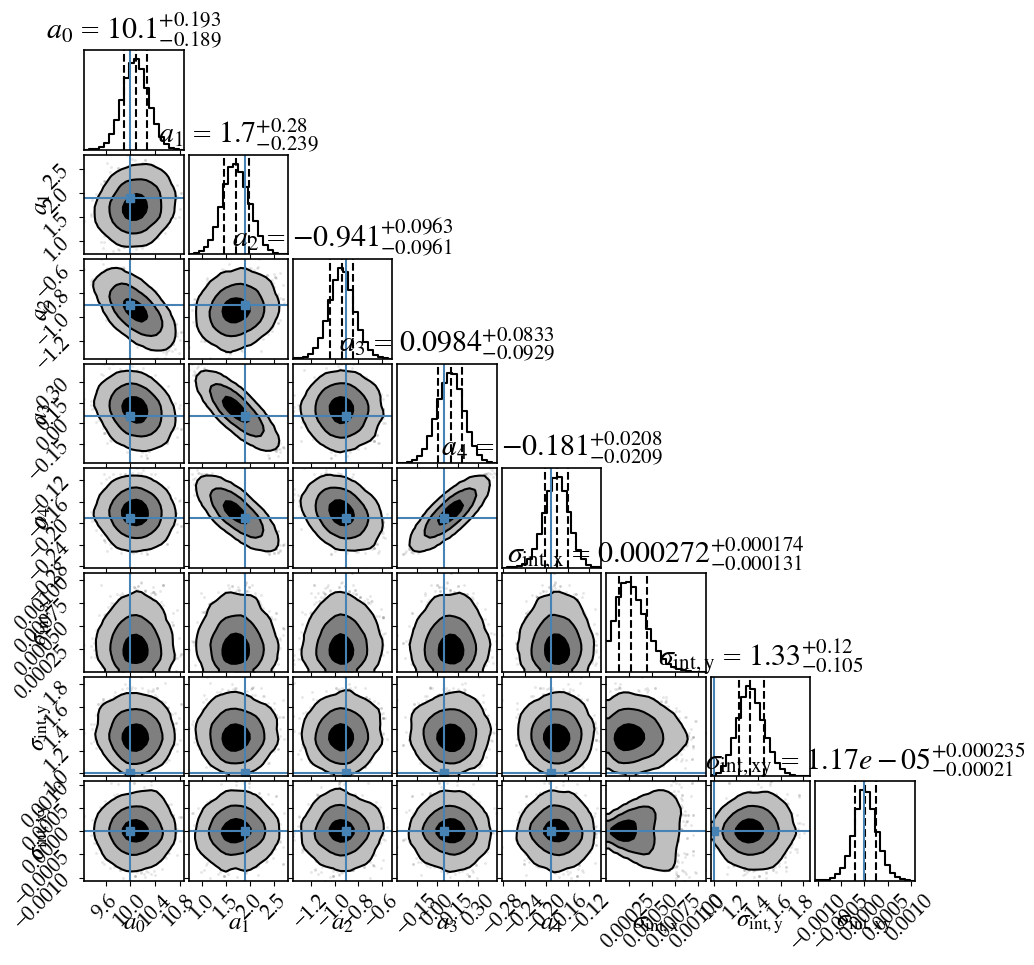

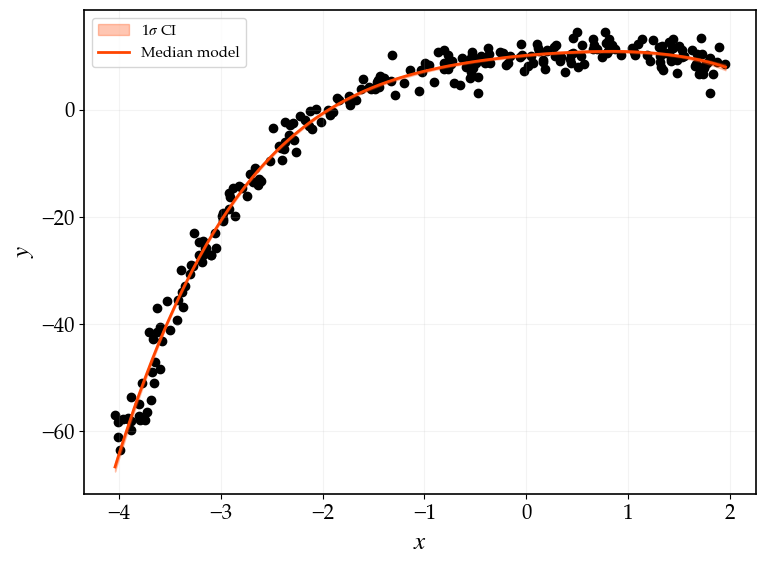

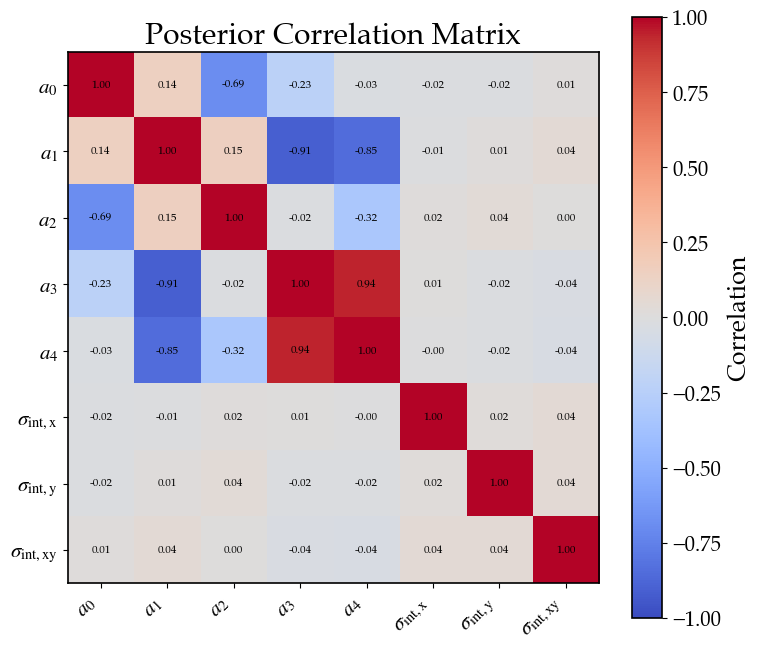


------------------------------------------
Posterior Coefficients
------------------------------------------
a_0  = 1.008326e+01 (+1.931397e-01, -1.885086e-01)
a_1  = 1.701917e+00 (+2.803611e-01, -2.394834e-01)
a_2  = -9.410926e-01 (+9.625142e-02, -9.613211e-02)
a_3  = 9.843962e-02 (+8.334616e-02, -9.287776e-02)
a_4  = -1.805183e-01 (+2.076292e-02, -2.085051e-02)

------------------------------------------
Cosmic Scatter
------------------------------------------
sigma_int_x  = 2.717854e-04 (+1.744529e-04, -1.314843e-04)
sigma_int_y  = 1.328253e+00 (+1.195121e-01, -1.046952e-01)
sigma_int_xy = 1.174770e-05 (+2.348239e-04, -2.099732e-04)

------------------------------------------
Covariance Matrix
------------------------------------------
[[ 3.79639501e-02  7.33634900e-03 -1.35145183e-02 -4.01271226e-03
  -1.28839218e-04 -5.40055128e-07 -5.08055717e-04  6.34084992e-07]
 [ 7.33634900e-03  6.92524494e-02  3.94074570e-03 -2.13465828e-02
  -4.75147835e-03 -3.52152952e-07  3.37695080e-04 

In [4]:
test = CosmicAnalysis(sampler, x_obs, y_obs, latex_eq=latex_eq, burnin = 2500, truths=coeffs_true, intrinsic_true=[sigma_x_int_true, sigma_y_int_true, sigma_xy_int_true])
# 

## okokugcina